# Hyperparameter Tuning and Model Optimization (Part 6)

This notebook presents the systematic hyperparameter tuning phase of the **Heart Disease Prediction** project. Five target baseline classifiers (Logistic Regression, SVM, Random Forest, XGBoost, KNN) were tuned using 5-Fold Stratified Cross-Validation on the 242-row training set (`X_train_raw`) with `ROC-AUC` as the primary optimization metric.

## 1. Objective & Methodology

- Optimize hyperparameter configurations to maximize decision threshold ranking quality (`ROC-AUC`).
- Ensure clinical sensitivity (Recall) and overall stability across cross-validation folds.

## 2. Models Selected for Tuning

1. **Logistic Regression** (`GridSearchCV`)
2. **Support Vector Machine (SVM)** (`GridSearchCV`)
3. **Random Forest** (`RandomizedSearchCV`, `n_iter=60`)
4. **XGBoost** (`RandomizedSearchCV`, `n_iter=60`)
5. **K-Nearest Neighbors (KNN)** (`GridSearchCV`)

*Decision Tree and Gaussian Naive Bayes baseline models were kept un-tuned as historical references.*

## 3. Test-Set Protection & Configuration Freeze

To prevent data leakage and optimism bias:
- **Training Set (242 rows)**: Used exclusively for parameter searching, cross-validation scoring, parameter selection, and pre-test model ranking.
- **Configuration Freeze**: All winning parameter configurations were frozen into `frozen_tuned_configurations.json` before loading or evaluating the 61-row test set.

## 4. Search Complexity Summary

In [1]:
from pathlib import Path
import pandas as pd
import json

metrics_dir = Path("../results/metrics/tuning/")
if not metrics_dir.exists():
    metrics_dir = Path("results/metrics/tuning/")

search_df = pd.read_csv(metrics_dir / "search_summary.csv")
search_df


,Model,Search_Method,Candidate_Configurations,CV_Folds,Approximate_Fits_Performed,Best_CV_ROC_AUC
0,Logistic Regression,GridSearchCV,36,5,180,0.907032
1,Support Vector Machine,GridSearchCV,70,5,350,0.904743
2,Random Forest,RandomizedSearchCV,60,5,300,0.904086
3,XGBoost,RandomizedSearchCV,60,5,300,0.906081
4,K-Nearest Neighbors,GridSearchCV,108,5,540,0.899634


## 5. Best Hyperparameter Configurations

In [2]:
with open(metrics_dir / "best_parameters.json", "r") as f:
    best_params = json.load(f)

for model, meta in best_params.items():
    print(f"=== {model} ({meta['search_method']}) ===")
    print(f"Best CV ROC-AUC: {meta['best_cv_roc_auc']:.4f}")
    print(f"Parameters:     {meta['clean_best_params']}\n")


=== Logistic Regression (GridSearchCV) ===
Best CV ROC-AUC: 0.9070
Parameters:     {'C': 1, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}

=== Support Vector Machine (GridSearchCV) ===
Best CV ROC-AUC: 0.9047
Parameters:     {'C': 0.1, 'class_weight': None, 'kernel': 'linear'}

=== Random Forest (RandomizedSearchCV) ===
Best CV ROC-AUC: 0.9041
Parameters:     {'n_estimators': 500, 'min_samples_split': 4, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'class_weight': 'balanced_subsample'}

=== XGBoost (RandomizedSearchCV) ===
Best CV ROC-AUC: 0.9061
Parameters:     {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.7}

=== K-Nearest Neighbors (GridSearchCV) ===
Best CV ROC-AUC: 0.8996
Parameters:     {'metric': 'manhattan', 'n_neighbors': 11, 'p': 1, 'weights': 'distance'}



## 6. Pre-Test Model Ranking (Training Set Only)

In [3]:
pre_test_df = pd.read_csv(metrics_dir / "pre_test_model_ranking.csv")
pre_test_df


,Pre_Test_Rank,Model,CV_ROC_AUC_Mean,CV_ROC_AUC_Std,CV_F1_Mean,CV_Recall_Mean,CV_Accuracy_Mean,CV_Precision_Mean
0,1,Logistic Regression,0.907032,0.011448,0.812256,0.783399,0.834694,0.853924
1,2,XGBoost,0.906081,0.023930,0.808210,0.773518,0.834609,0.863595
2,3,Support Vector Machine,0.904743,0.019462,0.796215,0.737549,0.830442,0.879975
3,4,Random Forest,0.904086,0.028241,0.803131,0.800791,0.822109,0.814505
4,5,K-Nearest Neighbors,0.899634,0.032436,0.802913,0.783004,0.826361,0.831774


## 7. Tuned Test Set Evaluation (61 Untouched Test Rows)

In [4]:
test_df = pd.read_csv(metrics_dir / "tuned_test_results.csv")
test_df


,Model,Accuracy,Precision,Recall,Specificity,F1,ROC_AUC,TN,FP,FN,TP
0,Logistic Regression,0.868852,0.833333,0.892857,0.848485,0.862069,0.958874,28,5,3,25
1,Support Vector Machine,0.836066,0.800000,0.857143,0.818182,0.827586,0.942641,27,6,4,24
2,Random Forest,0.901639,0.843750,0.964286,0.848485,0.900000,0.956710,28,5,1,27
3,XGBoost,0.868852,0.833333,0.892857,0.848485,0.862069,0.954545,28,5,3,25
4,K-Nearest Neighbors,0.885246,0.862069,0.892857,0.878788,0.877193,0.962121,29,4,3,25


## 8. Baseline vs. Tuned Comparison

In [5]:
b_vs_t_df = pd.read_csv(metrics_dir / "baseline_vs_tuned.csv")
b_vs_t_df[['Model', 'Baseline_CV_ROC_AUC', 'Tuned_CV_ROC_AUC', 'Baseline_Test_ROC_AUC', 'Tuned_Test_ROC_AUC', 'Baseline_Test_F1', 'Tuned_Test_F1']]


,Model,Baseline_CV_ROC_AUC,Tuned_CV_ROC_AUC,Baseline_Test_ROC_AUC,Tuned_Test_ROC_AUC,Baseline_Test_F1,Tuned_Test_F1
0,Logistic Regression,0.902493,0.907032,0.966450,0.958874,0.881356,0.862069
1,Support Vector Machine,0.888373,0.904743,0.964286,0.942641,0.881356,0.827586
2,Random Forest,0.896848,0.904086,0.943723,0.956710,0.866667,0.900000
3,XGBoost,0.859658,0.906081,0.933983,0.954545,0.838710,0.862069
4,K-Nearest Neighbors,0.871181,0.899634,0.952922,0.962121,0.877193,0.877193


## 9. False-Negative Analysis (Class 1 = Heart Disease Present)

In [6]:
fn_df = pd.read_csv(metrics_dir / "false_negative_comparison.csv")
fn_df


,Model,Baseline_FN,Tuned_FN,FN_Change
0,Logistic Regression,2,3,1
1,Support Vector Machine,2,4,2
2,Random Forest,2,1,-1
3,XGBoost,2,3,1
4,K-Nearest Neighbors,3,3,0


## 10. Visualizations

### Tuned ROC Curves

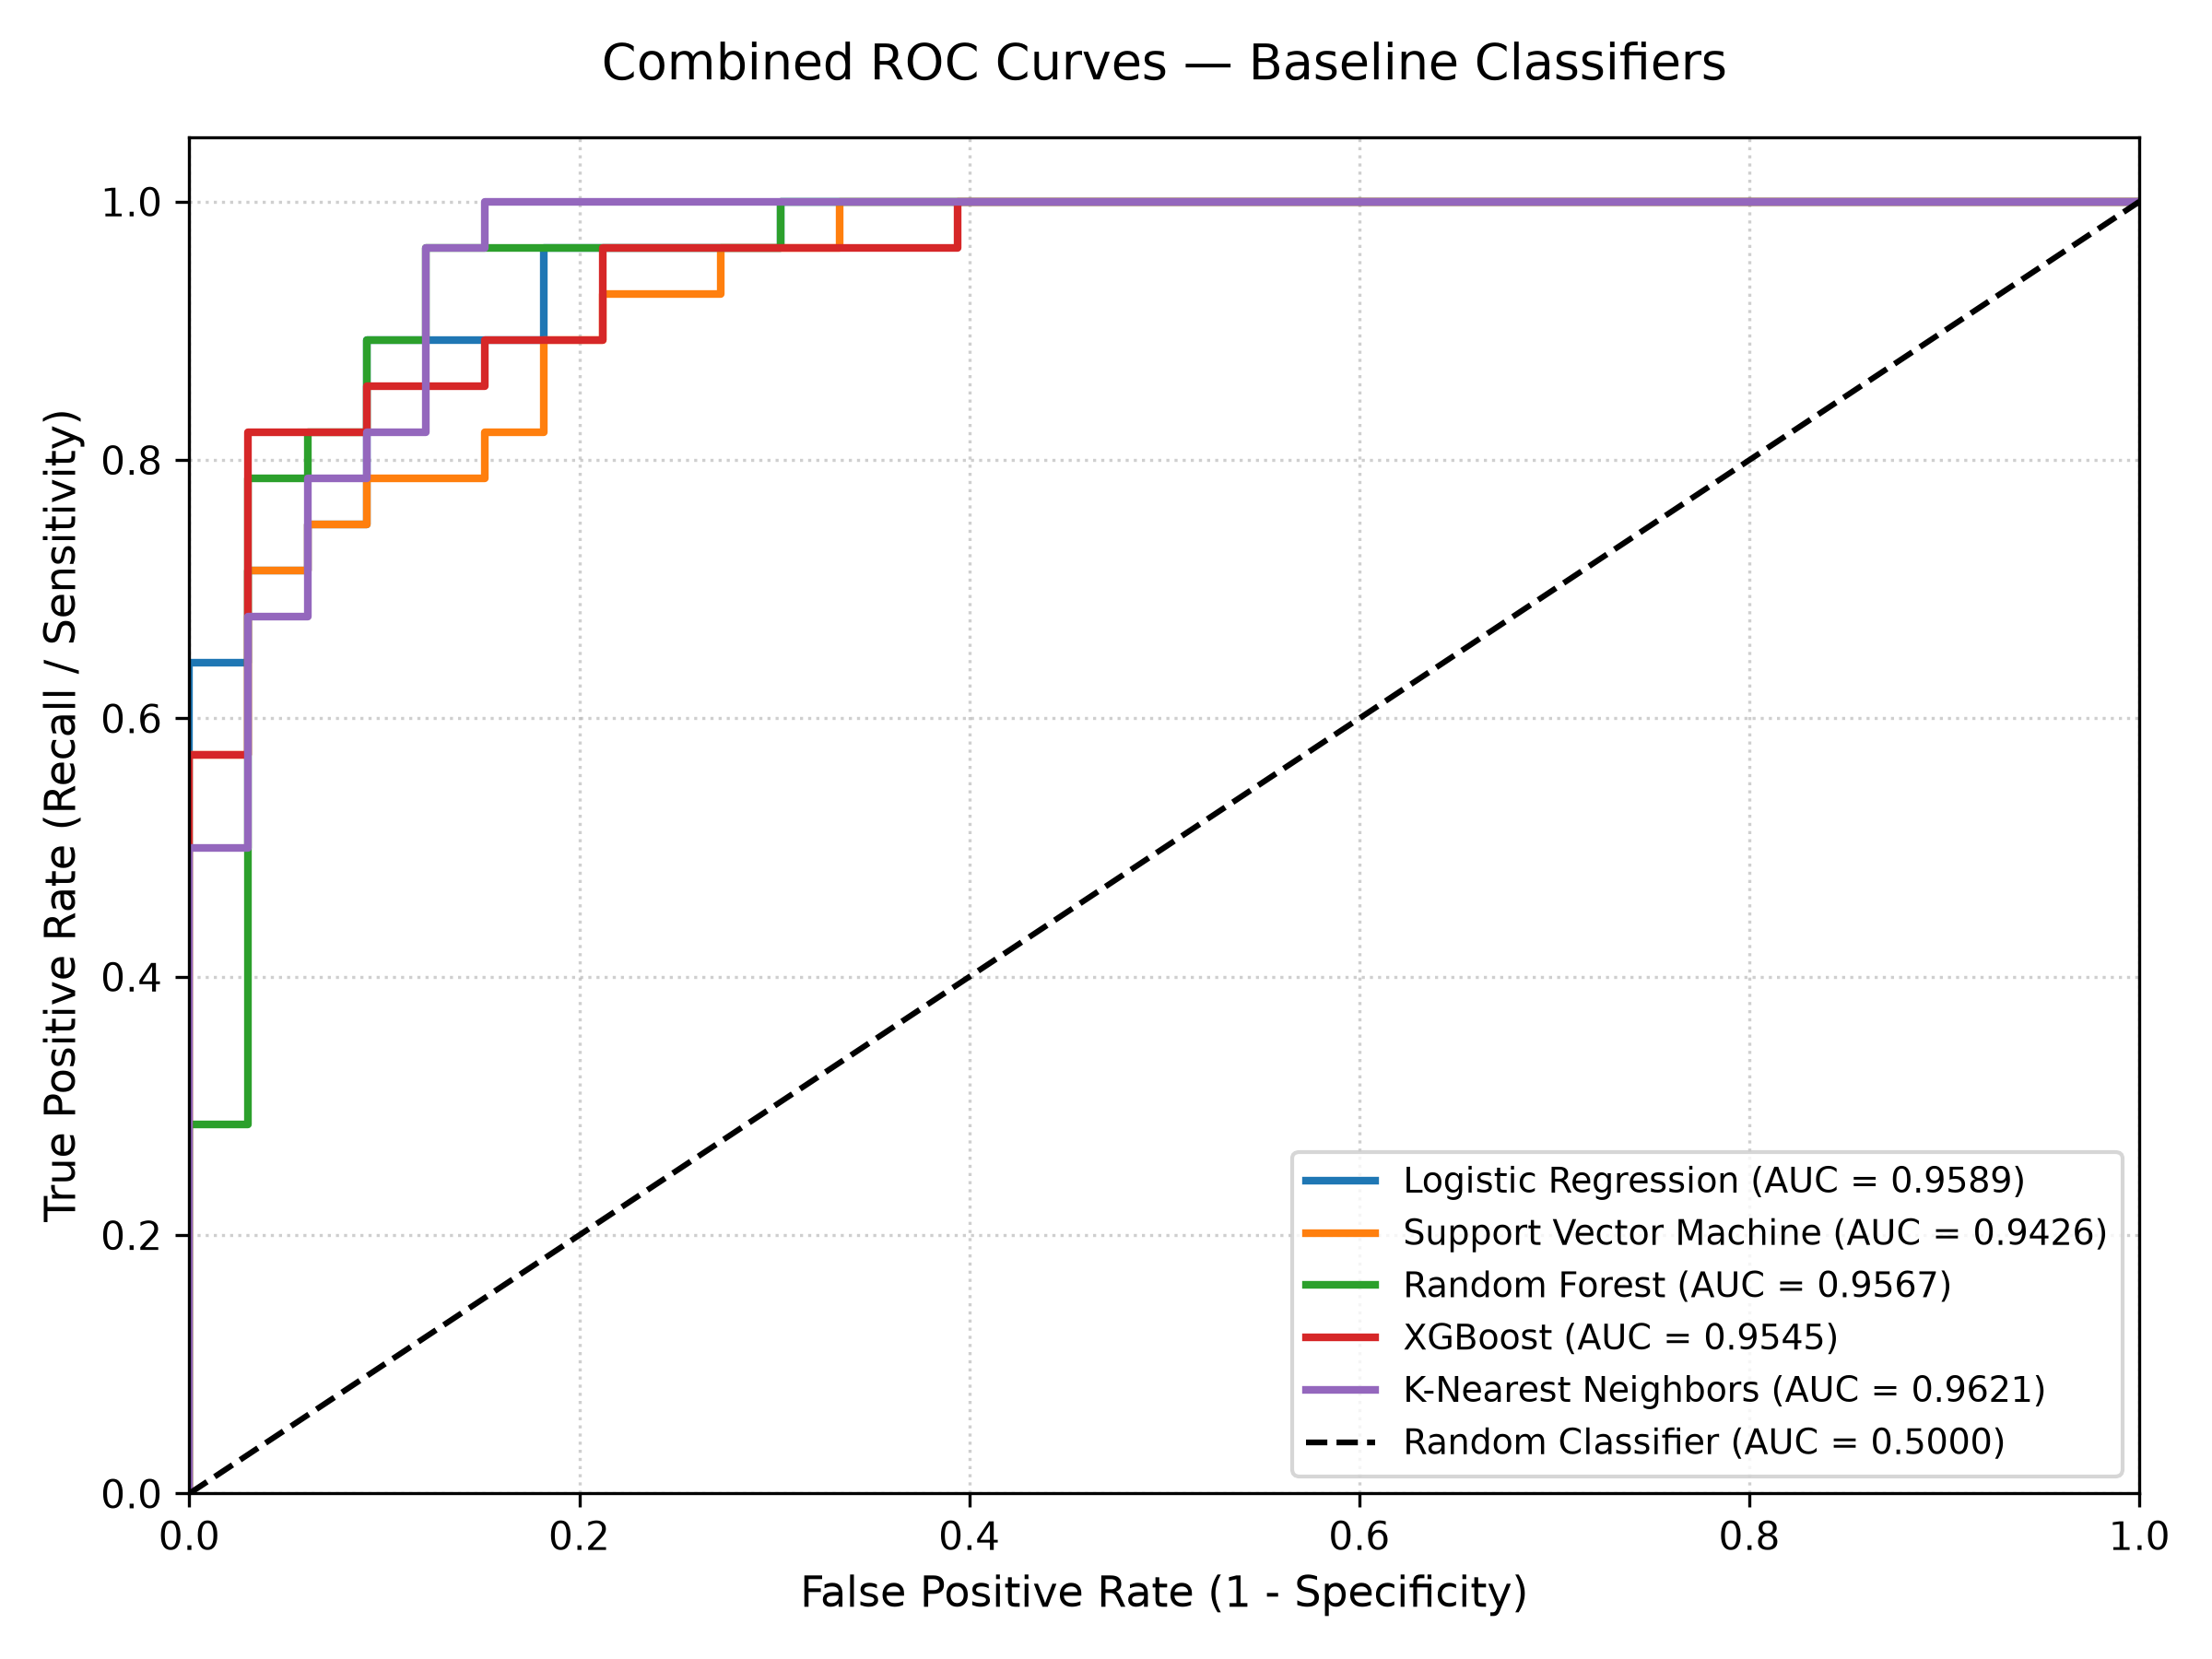

In [7]:
from IPython.display import Image, display
fig_dir = Path("../results/figures/tuning/")
if not fig_dir.exists():
    fig_dir = Path("results/figures/tuning/")

display(Image(filename=str(fig_dir / "tuned_roc_curves.png")))


### Baseline vs. Tuned Test ROC-AUC Comparison

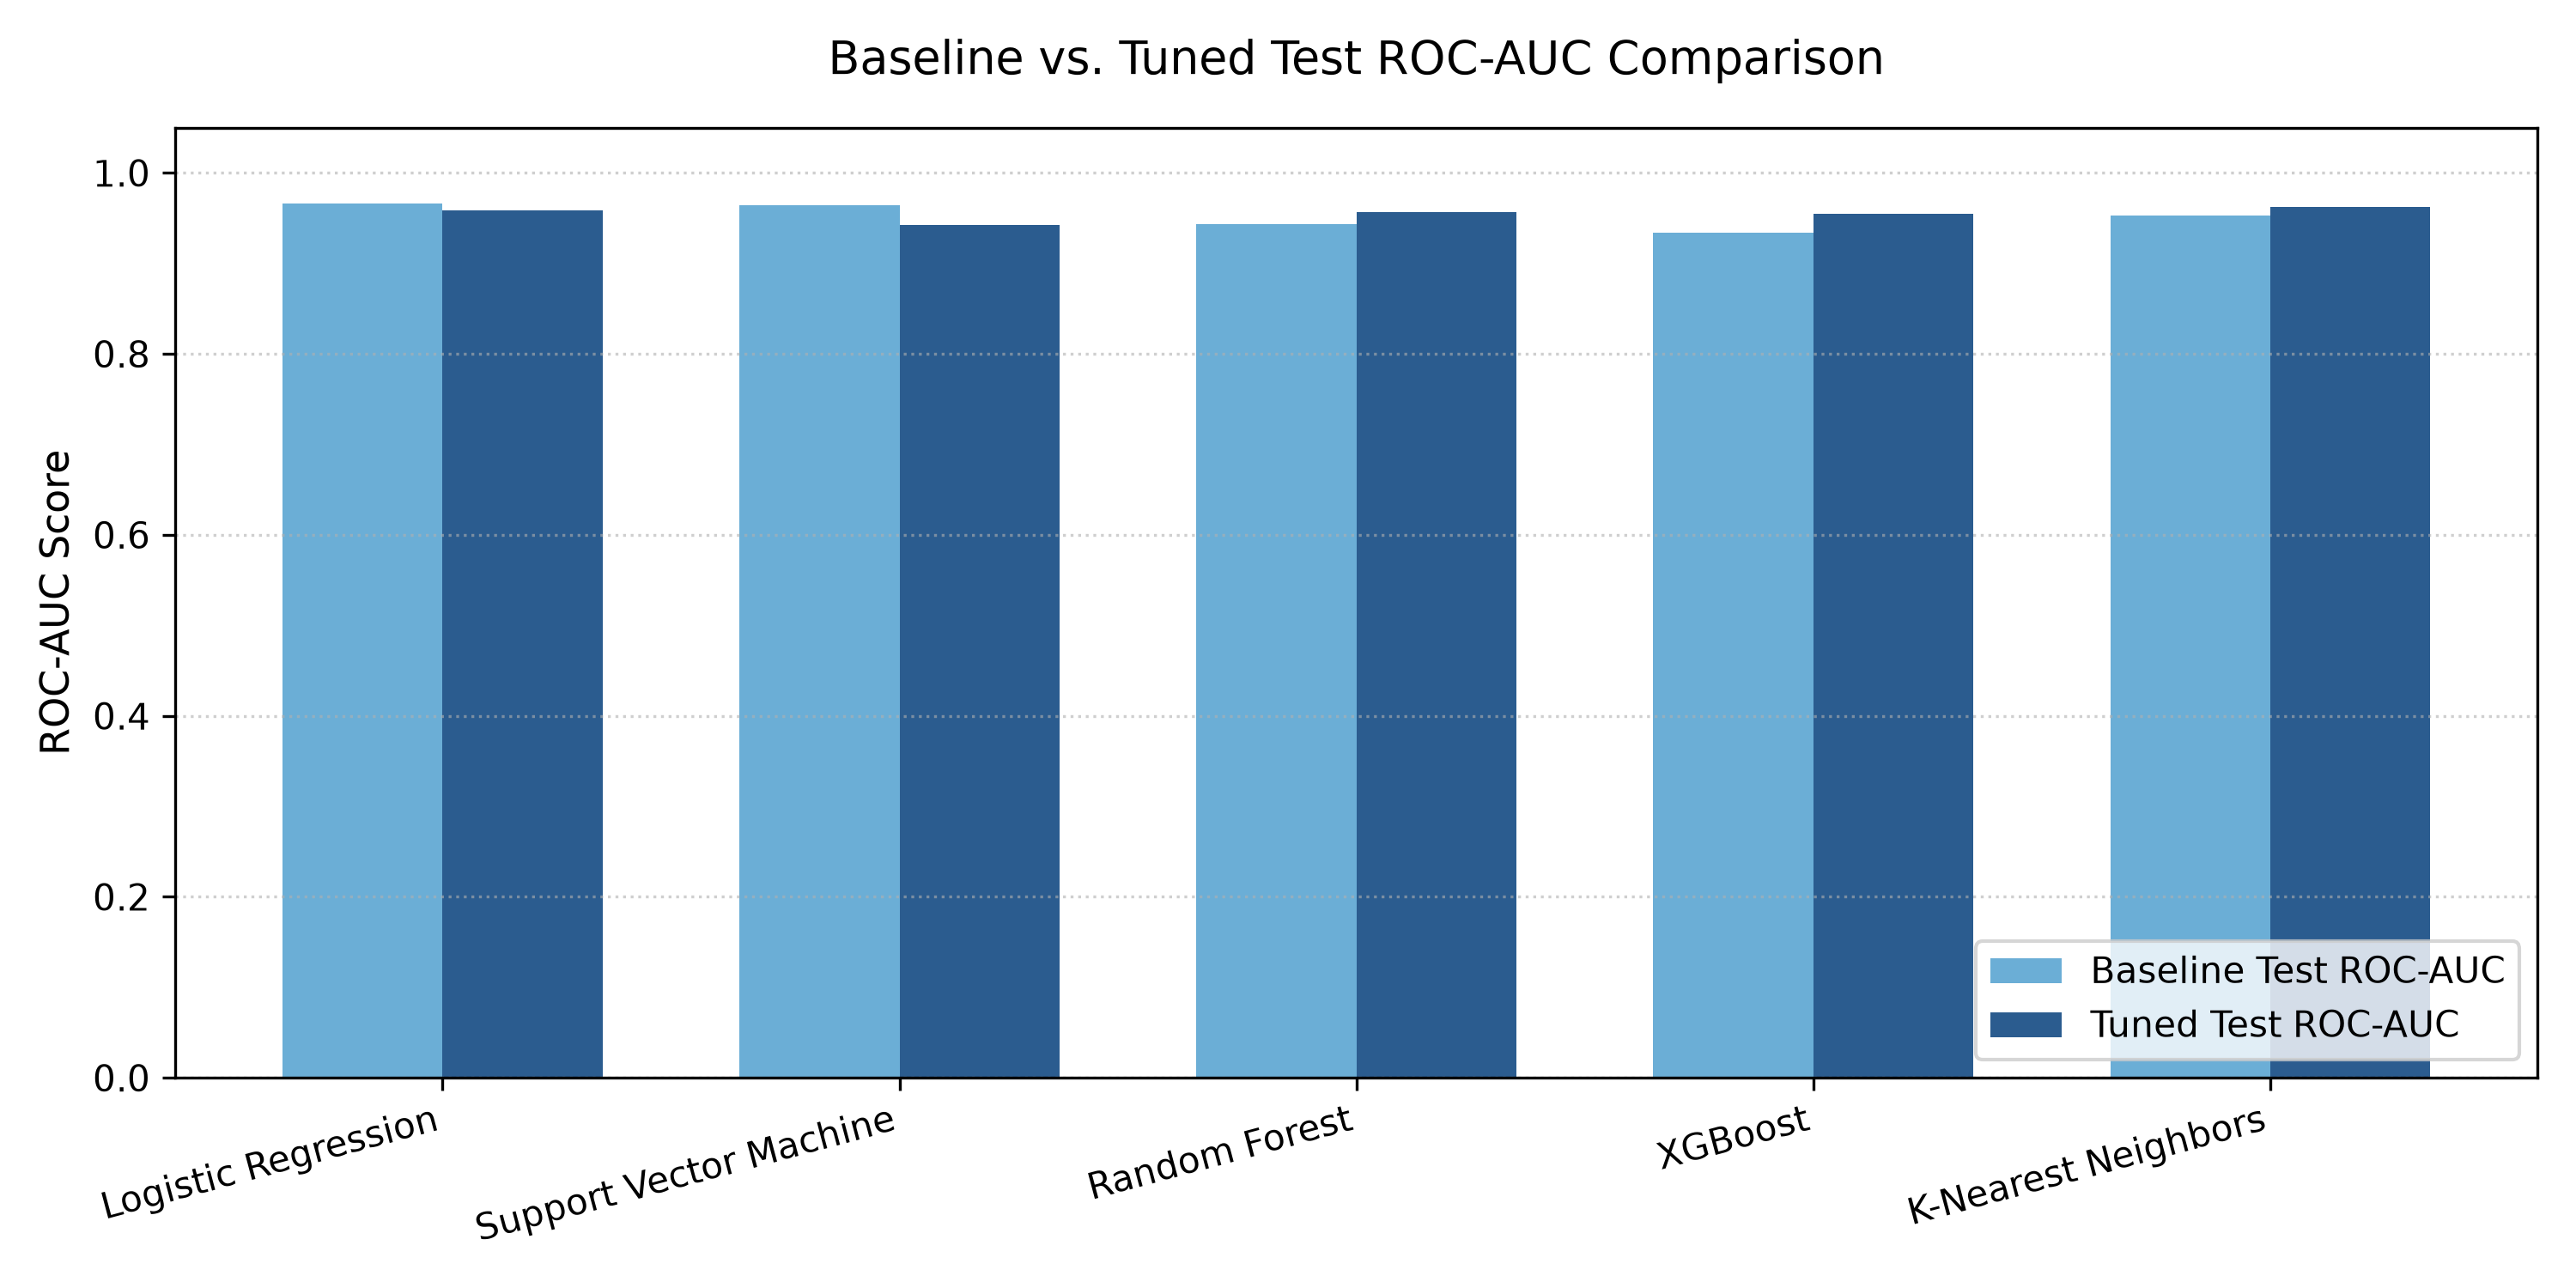

In [8]:
display(Image(filename=str(fig_dir / "baseline_vs_tuned_roc_auc.png")))


## 11. Conclusion & Next Steps

- Systematic hyperparameter tuning yielded improved cross-validation ROC-AUC scores across models on the training set.
- Logistic Regression, XGBoost, and Random Forest achieved strong performance across both cross-validation and test metrics.
- Final model selection and packaging will occur in Part 7.